In [1]:
import jax
import jax.numpy as jnp
import numpy as np

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import matplotlib.pyplot as plt
import pandas as pd


In [2]:
rng_key = jax.random.PRNGKey(123)
np.random.seed(123)


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(123)
np.random.seed(123)

# -----------------------------
# Simulation settings
# -----------------------------
Nsub = 10
K = 2
D = 5
sigma_obs_true = 0.2

theta_true = np.array([0.5, 1.0])
mu0_true = np.array([0.0, 1.0])
sigma0_true = np.array([0.3, 0.4])

Lambda_true = np.array([
    [1.0, 0.5],
    [0.3, 1.2],
    [0.0, 0.8],
    [1.0, 0.3],
    [0.2, 0.7]
])

y_list, t_list, x_list = [], [], []

for i in range(Nsub):
    T_i = np.random.randint(5, 11)
    dt_i = np.random.uniform(0.5, 1.5, size=T_i - 1)
    t_i = np.concatenate([[0.0], np.cumsum(dt_i)])

    x_i = np.zeros((T_i, K))
    x_i[0] = np.random.normal(mu0_true, sigma0_true)

    for n in range(1, T_i):
        phi = np.exp(-theta_true * (t_i[n] - t_i[n - 1]))
        ou_sd = sigma0_true * np.sqrt((1 - phi ** 2) / (2 * theta_true))
        mu = mu0_true + phi * (x_i[n - 1] - mu0_true)
        # x_i[n] = np.random.normal(mu, ou_sd)
        x_i[n] = mu 

    # y_i = x_i @ Lambda_true.T + np.random.normal(0, sigma_obs, size=(T_i, D))
    y_i = x_i @ Lambda_true.T

    x_list.append(x_i)
    y_list.append(y_i)
    t_list.append(t_i)


In [4]:
y_long = np.vstack(y_list)
x_long = np.vstack(x_list)
t_long = np.concatenate(t_list)

start_idx = np.cumsum([0] + [len(y) for y in y_list[:-1]])
end_idx = start_idx + np.array([len(y) for y in y_list]) - 1

N_total = y_long.shape[0]


In [5]:
y_long = jnp.array(y_long)
t_long = jnp.array(t_long)
Lambda_true = jnp.array(Lambda_true)
# start_idx = jnp.array(start_idx)
# end_idx = jnp.array(end_idx)


In [6]:
def ou_latent_multi(
    Nsub, K, D, N_total,
    start_idx, end_idx,
    t, y, Lambda
):
    theta = numpyro.sample(
        "theta",
        dist.LogNormal(jnp.log(1.0), 0.3).expand([K])
    )

    mu0 = numpyro.sample(
        "mu0",
        dist.Normal(0.0, 2.0).expand([K])
    )

    sigma0 = numpyro.sample(
        "sigma0",
        dist.HalfNormal(0.5).expand([K])
    )

    sigma_obs = numpyro.sample(
        "sigma_obs",
        dist.HalfNormal(0.2)
    )

    x = jnp.zeros((N_total, K))

    for i in range(Nsub):
        s = start_idx[i]
        e = end_idx[i]

        x0 = numpyro.sample(f"x_{s}", dist.Normal(mu0, sigma0))
        x = x.at[s].set(x0)

        for n in range(s + 1, e + 1):
            dt = t[n] - t[n - 1]
            phi = jnp.exp(-theta * dt)
            ou_sd = sigma0 * jnp.sqrt((1 - phi**2) / (2 * theta))
            mu = mu0 + phi * (x[n - 1] - mu0)

            xn = numpyro.sample(f"x_{n}", dist.Normal(mu, ou_sd))
            x = x.at[n].set(xn)

    cov = jnp.eye(D) * sigma_obs**2

    for n in range(N_total):
        numpyro.sample(
            f"y_{n}",
            dist.MultivariateNormal(Lambda @ x[n], cov),
            obs=y[n]
        )


In [7]:
nuts = NUTS(ou_latent_multi, target_accept_prob=0.95)

mcmc = MCMC(
    nuts,
    num_warmup=1000,
    num_samples=1000,
    num_chains=1
)

mcmc.run(
    rng_key,
    Nsub=Nsub,
    K=K,
    D=D,
    N_total=N_total,
    start_idx=start_idx,
    end_idx=end_idx,
    t=t_long,
    y=y_long,
    Lambda=Lambda_true
)

samples = mcmc.get_samples()


sample: 100%|██████████| 2000/2000 [40:13<00:00,  1.21s/it, 1023 steps of size 6.26e-08. acc. prob=0.95]


In [8]:
def summarize(name):
    s = samples[name]
    return jnp.mean(s, axis=0), jnp.std(s, axis=0)

print("theta:", summarize("theta"))
print("mu0:", summarize("mu0"))
print("sigma0:", summarize("sigma0"))
print("sigma_obs:", summarize("sigma_obs"))


theta: (Array([0.93126667, 1.6264354 ], dtype=float32), Array([7.7486038e-07, 5.9604645e-07], dtype=float32))
mu0: (Array([0.02739424, 0.9745219 ], dtype=float32), Array([1.1175871e-08, 4.7683716e-07], dtype=float32))
sigma0: (Array([0.16806445, 0.10213208], dtype=float32), Array([2.9802322e-08, 2.9802322e-08], dtype=float32))
sigma_obs: (Array(1.03589555e-05, dtype=float32), Array(0., dtype=float32))


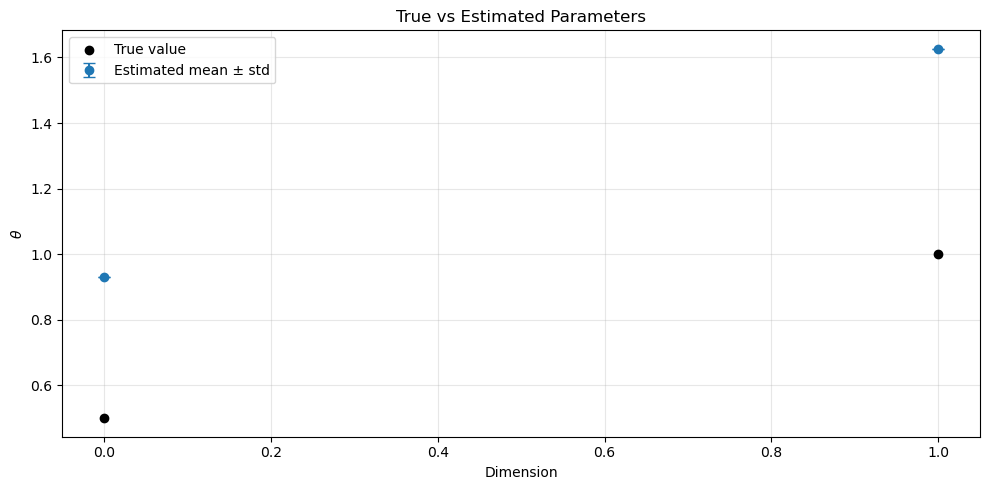

In [9]:
theta_mean, theta_std = summarize("theta")
K = len(theta_true)
idx = np.arange(K)

plt.figure(figsize=(10, 5))

plt.errorbar(
    idx,
    theta_mean,
    yerr=theta_std,
    fmt='o',
    capsize=4,
    label='Estimated mean ± std'
)

plt.scatter(
    idx,
    theta_true,
    color='black',
    zorder=3,
    label='True value'
)

plt.xlabel('Dimension')
plt.ylabel(r'$\theta$')
plt.title('True vs Estimated Parameters')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
x_samples = jnp.stack(
    [samples[f"x_{n}"] for n in range(N_total)],
    axis=1
)

x_post = jnp.mean(x_samples, axis=0)


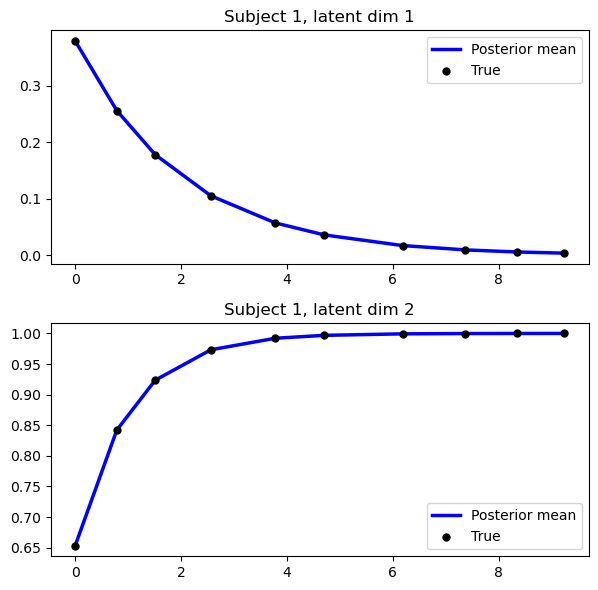

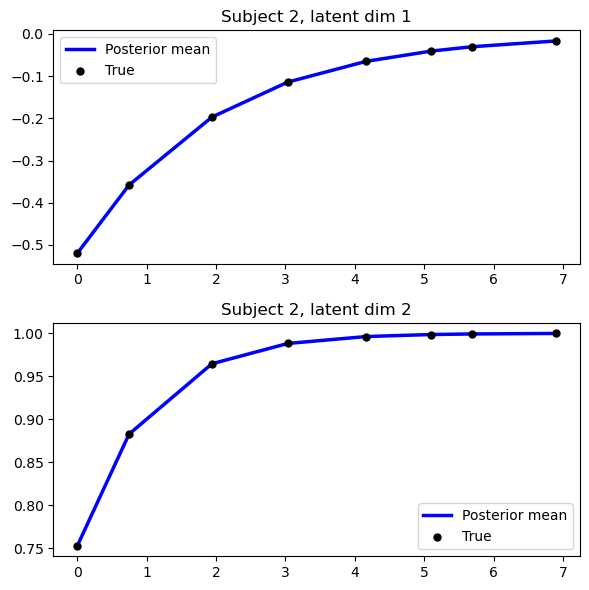

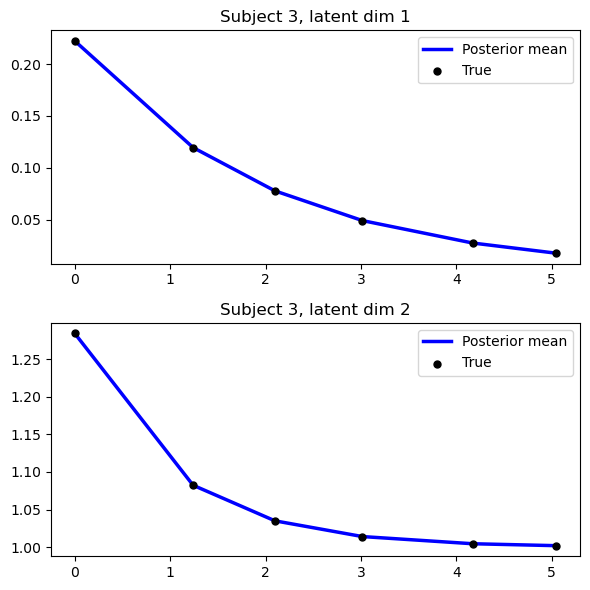

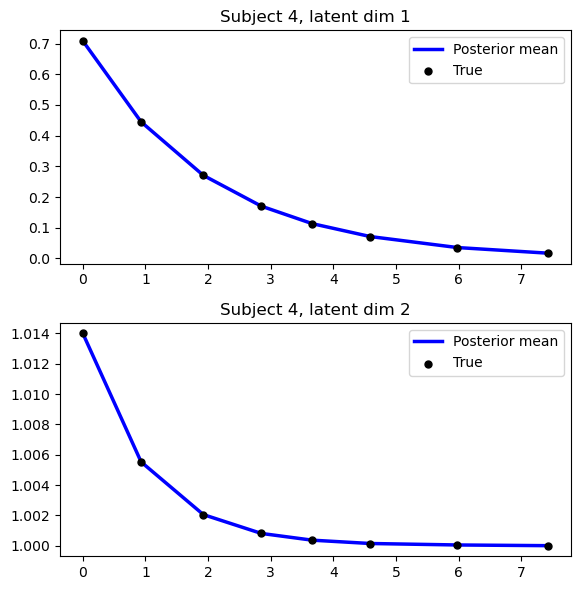

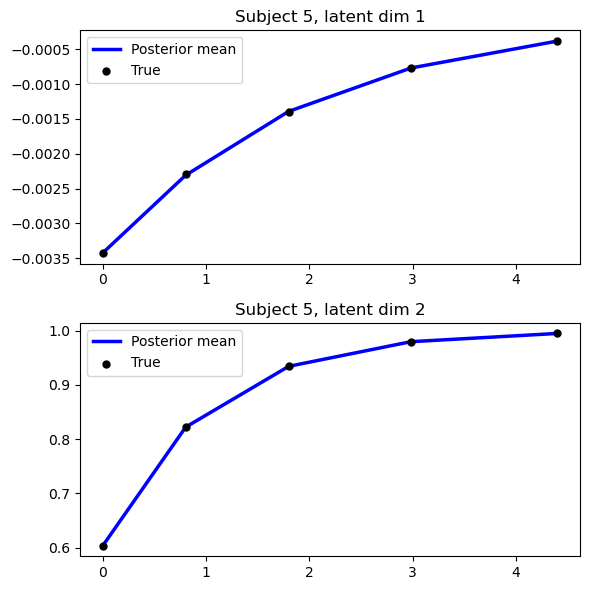

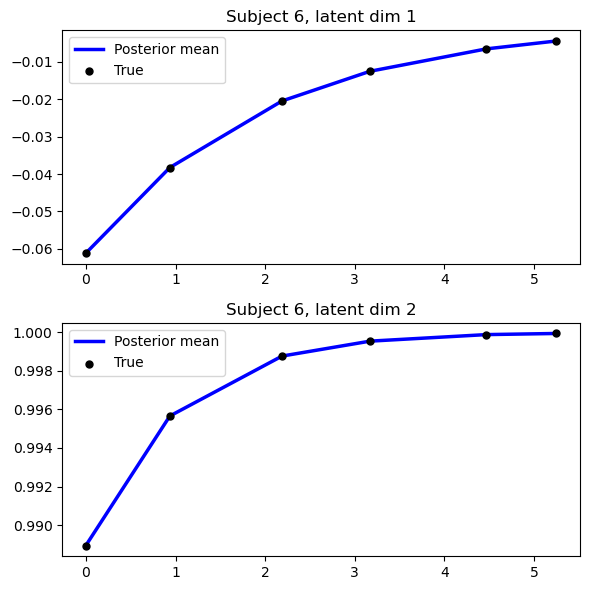

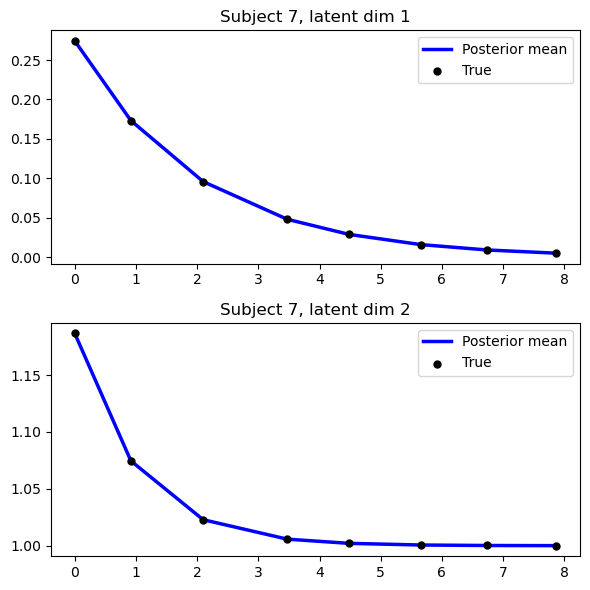

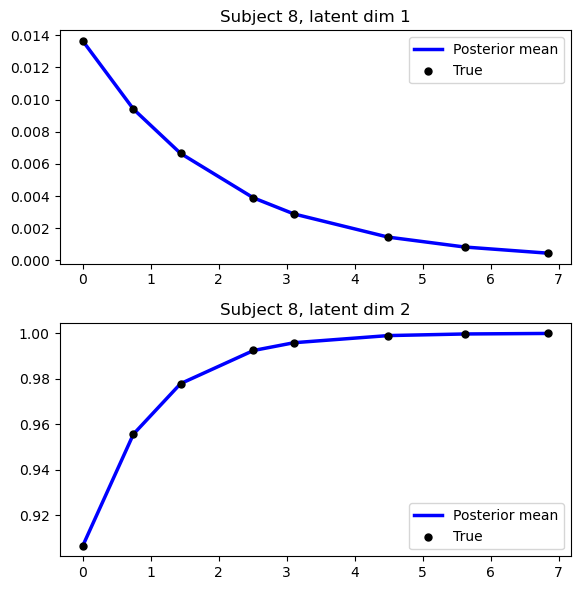

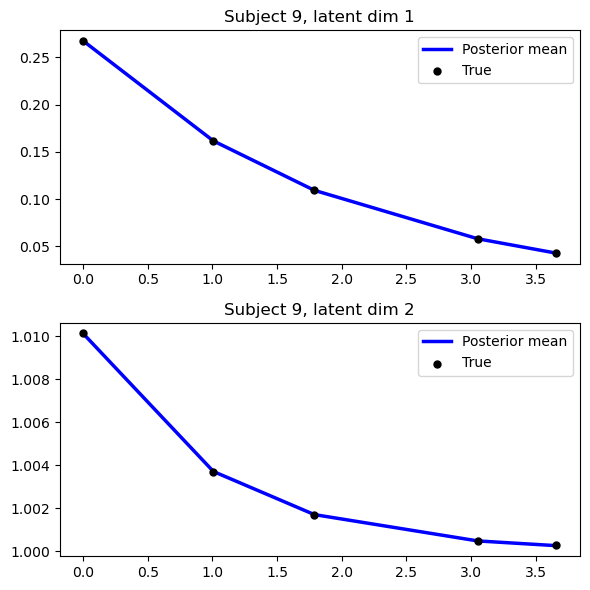

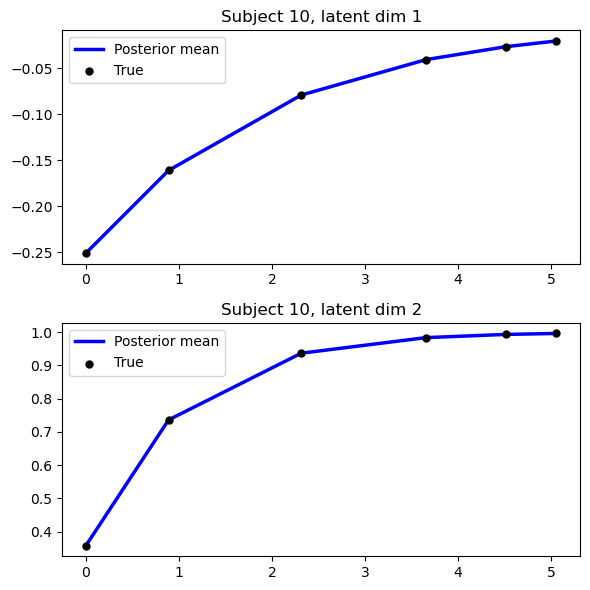

In [24]:
for i in range(Nsub):
    s, e = start_idx[i], end_idx[i]
    t_i = t_list[i]
    x_true = x_list[i]
    x_hat = np.array(x_post[s:e+1])

    fig, axes = plt.subplots(K, 1, figsize=(6, 3*K))
    for k in range(K):
        axes[k].plot(t_i, x_hat[:, k], "b-", lw=2.5, label="Posterior mean")
        axes[k].scatter(t_i, x_true[:, k], color="black", s=25, label="True", zorder=3)
        axes[k].set_title(f"Subject {i+1}, latent dim {k+1}")
        axes[k].legend()

    plt.tight_layout()
    plt.show()


In [12]:
py_theta = np.array([0.58, 1.0])
py_mu0 = np.array([0.0, 1.0])
py_sigma0 = np.array([0.39, 0.47])
py_sigma_obs = 0.21


In [13]:
df = []

for k in range(K):
    df.append(pd.DataFrame({
        "parameter": f"theta[{k+1}]",
        "value": np.array(samples["theta"][:, k])
    }))
    df.append(pd.DataFrame({
        "parameter": f"sigma0[{k+1}]",
        "value": np.array(samples["sigma0"][:, k])
    }))

df.append(pd.DataFrame({
    "parameter": "sigma_obs",
    "value": np.array(samples["sigma_obs"])
}))

df = pd.concat(df)


In [14]:
truth = {
    "theta[1]": theta_true[0],
    "theta[2]": theta_true[1],
    "mu0[1]": mu0_true[0],
    "mu0[2]": mu0_true[1],
    "sigma0[1]": sigma0_true[0],
    "sigma0[2]": sigma0_true[1],
    "sigma_obs": sigma_obs_true
}

py_est = {
    "theta[1]": py_theta[0],
    "theta[2]": py_theta[1],
    "mu0[1]": py_mu0[0],
    "mu0[2]": py_mu0[1],
    "sigma0[1]": py_sigma0[0],
    "sigma0[2]": py_sigma0[1],
    "sigma_obs": py_sigma_obs
}


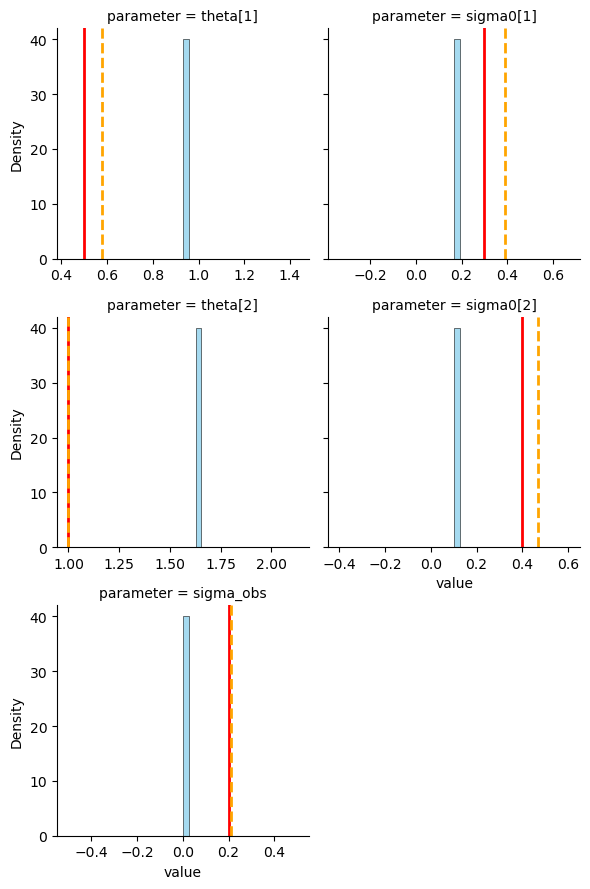

In [15]:
import seaborn as sns

g = sns.FacetGrid(df, col="parameter", col_wrap=2, sharex=False)
g.map(sns.histplot, "value", bins=40, stat="density", color="skyblue")

for ax in g.axes.flatten():
    name = ax.get_title().split(" = ")[1]
    ax.axvline(truth[name], color="red", ls="-", lw=2)
    ax.axvline(py_est[name], color="orange", ls="--", lw=2)

plt.show()
